# Clasificación no supervisada: segmentación de vinos

Este notebook aplica **UMAP + HDBSCAN** al dataset Wine de UCI. Las etiquetas reales se reservan exclusivamente para la evaluación final: no intervienen en el escalado, la reducción dimensional, la búsqueda de hiperparámetros ni el entrenamiento del clustering.

## 1. Preparación

In [1]:
import warnings

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap.umap_ as umap

from scipy.optimize import linear_sum_assignment
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    confusion_matrix,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
pd.set_option("display.max_columns", 100)

C:\Users\rbenitez\Documents\Master IA\master-ia-agentica\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y análisis exploratorio

In [2]:
wine = fetch_ucirepo(id=109)
X_raw = wine.data.features.copy()
y_true = wine.data.targets["class"].astype(int).copy()

print(f"Filas: {X_raw.shape[0]} | Variables: {X_raw.shape[1]}")
print(f"Valores ausentes: {X_raw.isna().sum().sum()}")
display(X_raw.head())

Filas: 178 | Variables: 13
Valores ausentes: 0


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malicacid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


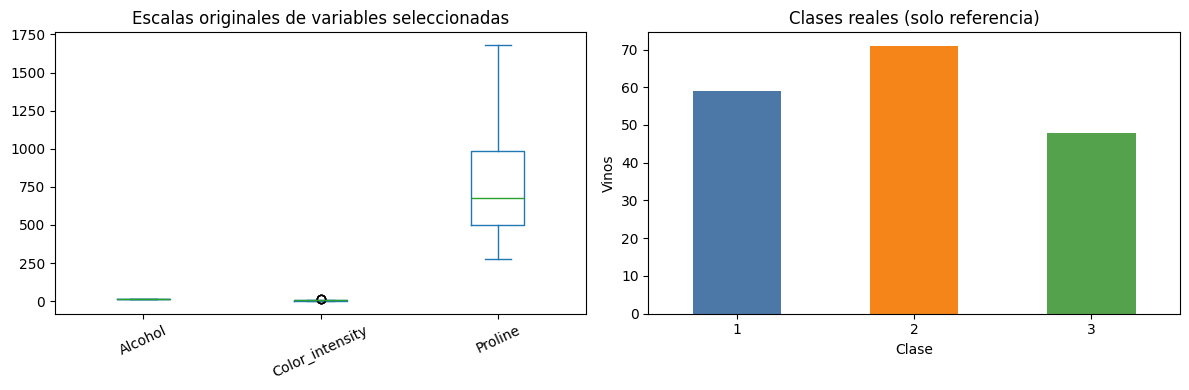

In [3]:
display(X_raw.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X_raw[["Alcohol", "Color_intensity", "Proline"]].plot(kind="box", ax=axes[0])
axes[0].set_title("Escalas originales de variables seleccionadas")
axes[0].tick_params(axis="x", rotation=25)

y_true.value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518", "#54A24B"], rot=0)
axes[1].set_title("Clases reales (solo referencia)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Vinos")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Todas las variables usadas por el algoritmo son características químicas. La etiqueta `class` permanece fuera de `X`. La imputación y el escalado se encapsulan en un pipeline reproducible.

In [4]:
feature_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_scaled = feature_pipeline.fit_transform(X_raw)
print(f"Matriz de modelado: {X_scaled.shape}")
print(f"Media absoluta después de escalar: {np.abs(X_scaled.mean(axis=0)).max():.2e}")

Matriz de modelado: (178, 13)
Media absoluta después de escalar: 8.38e-16


## 4. Proyección bidimensional con UMAP

C:\Users\rbenitez\Documents\Master IA\master-ia-agentica\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


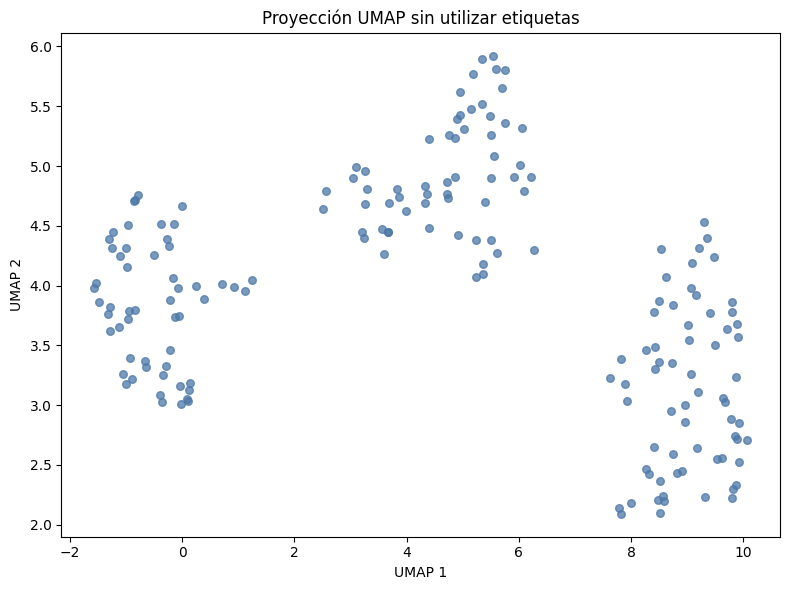

In [5]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=2,
    metric="euclidean",
    random_state=SEED,
)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=30, alpha=0.75, color="#4C78A8")
plt.title("Proyección UMAP sin utilizar etiquetas")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 5. Selección no supervisada de HDBSCAN

Se explora una rejilla pequeña. La selección usa solamente dos señales internas: `relative_validity_` de HDBSCAN y la cobertura de puntos no clasificados como ruido. Las etiquetas reales no se consultan.

In [6]:
search_rows = []

for min_cluster_size in [3, 5, 8, 10, 12, 15, 20]:
    for min_samples in [1, 3, 5, 8, 10]:
        candidate = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            gen_min_span_tree=True,
        )
        labels = candidate.fit_predict(X_umap)
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        coverage = mask.mean()
        validity = float(candidate.relative_validity_)
        internal_score = validity * coverage if 2 <= n_clusters <= 6 else -np.inf

        search_rows.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "coverage": coverage,
            "relative_validity": validity,
            "internal_score": internal_score,
        })

search_results = pd.DataFrame(search_rows).sort_values("internal_score", ascending=False)
display(search_results.head(10).style.format({
    "coverage": "{:.3f}",
    "relative_validity": "{:.3f}",
    "internal_score": "{:.3f}",
}))

,min_cluster_size,min_samples,clusters,coverage,relative_validity,internal_score
25,15,1,3,1.000,0.701,0.701
15,10,1,3,1.000,0.701,0.701
10,8,1,3,1.000,0.701,0.701
30,20,1,3,1.000,0.701,0.701
20,12,1,3,1.000,0.701,0.701
1,3,3,3,1.000,0.597,0.597
31,20,3,3,1.000,0.597,0.597
26,15,3,3,1.000,0.597,0.597
16,10,3,3,1.000,0.597,0.597
11,8,3,3,1.000,0.597,0.597


In [7]:
best = search_results.iloc[0]
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=int(best["min_cluster_size"]),
    min_samples=int(best["min_samples"]),
    metric="euclidean",
    cluster_selection_method="eom",
    gen_min_span_tree=True,
    prediction_data=True,
)
cluster_labels = clusterer.fit_predict(X_umap)
valid_mask = cluster_labels != -1

n_clusters = len(set(cluster_labels[valid_mask]))
noise_ratio = 1 - valid_mask.mean()
silhouette = silhouette_score(X_umap[valid_mask], cluster_labels[valid_mask]) if n_clusters > 1 else np.nan

print(f"Parámetros seleccionados: min_cluster_size={int(best['min_cluster_size'])}, min_samples={int(best['min_samples'])}")
print(f"Clústeres encontrados: {n_clusters}")
print(f"Ruido: {noise_ratio:.2%}")
print(f"Silhouette sin ruido: {silhouette:.4f}")

Parámetros seleccionados: min_cluster_size=15, min_samples=1
Clústeres encontrados: 3
Ruido: 0.00%
Silhouette sin ruido: 0.7302


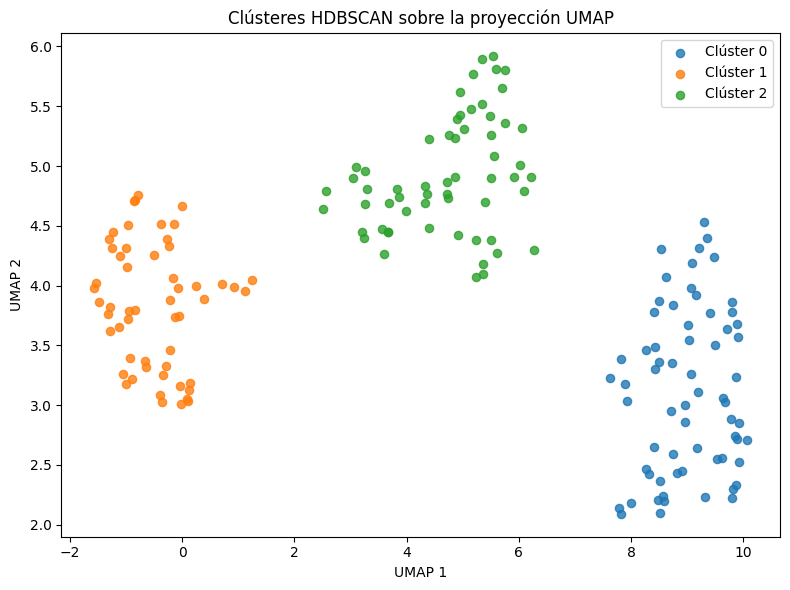

In [8]:
plt.figure(figsize=(8, 6))
for label in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == label
    name = "Ruido" if label == -1 else f"Clúster {label}"
    color = "#BDBDBD" if label == -1 else None
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], s=35, alpha=0.8, label=name, color=color)

plt.title("Clústeres HDBSCAN sobre la proyección UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Evaluación externa

Solo después de cerrar el modelo se comparan los clústeres con las clases reales. ARI y NMI son invariantes al nombre asignado a cada clúster. Para visualizar una matriz de confusión, la asignación clúster-clase se obtiene mediante el algoritmo húngaro y los puntos de ruido permanecen como `-1`.

In [9]:
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

valid_clusters = sorted(set(cluster_labels[valid_mask]))
true_classes = sorted(y_true.unique())
contingency = pd.crosstab(
    pd.Series(y_true[valid_mask].to_numpy(), name="clase"),
    pd.Series(cluster_labels[valid_mask], name="cluster"),
).reindex(index=true_classes, columns=valid_clusters, fill_value=0)

row_ind, col_ind = linear_sum_assignment(-contingency.to_numpy())
cluster_to_class = {
    contingency.columns[col]: contingency.index[row]
    for row, col in zip(row_ind, col_ind)
}
mapped_labels = np.array([cluster_to_class.get(label, -1) for label in cluster_labels])
accuracy_without_noise = (mapped_labels[valid_mask] == y_true.to_numpy()[valid_mask]).mean()

external_metrics = pd.Series({
    "adjusted_rand_index": ari,
    "normalized_mutual_information": nmi,
    "accuracy_sin_ruido_tras_mapeo": accuracy_without_noise,
    "cobertura": valid_mask.mean(),
    "silhouette_sin_ruido": silhouette,
}, name="resultado").to_frame()
display(external_metrics.style.format("{:.4f}"))
print("Mapeo clúster → clase:", cluster_to_class)

,resultado
adjusted_rand_index,0.8025
normalized_mutual_information,0.7955
accuracy_sin_ruido_tras_mapeo,0.9326
cobertura,1.0000
silhouette_sin_ruido,0.7302


Mapeo clúster → clase: {np.int64(0): np.int64(1), np.int64(2): np.int64(2), np.int64(1): np.int64(3)}


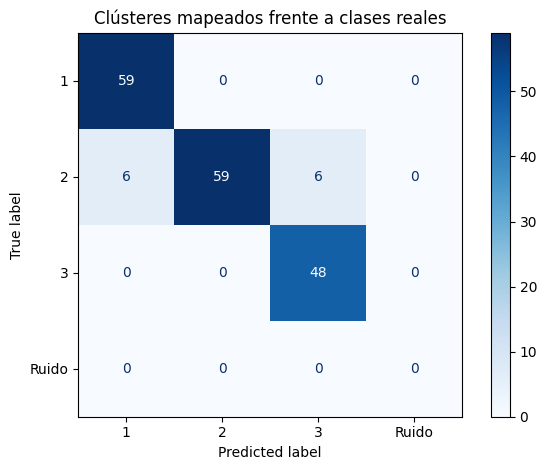

In [10]:
labels_for_matrix = true_classes + [-1]
matrix = confusion_matrix(y_true, mapped_labels, labels=labels_for_matrix)
disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[str(x) for x in true_classes] + ["Ruido"],
)
disp.plot(cmap="Blues")
plt.title("Clústeres mapeados frente a clases reales")
plt.tight_layout()
plt.show()

## 7. Conclusiones

- La etiqueta real quedó completamente aislada del proceso de entrenamiento y selección.
- UMAP facilita una representación local compacta; HDBSCAN determina automáticamente el número de clústeres y puede identificar ruido.
- ARI y NMI permiten evaluar la correspondencia con las clases conocidas sin depender de la numeración arbitraria de los clústeres.
- El resultado es exploratorio: para uso empresarial habría que comprobar estabilidad entre semillas, validar el significado operativo de cada segmento y monitorizar cambios en la distribución.